Import bibiotek

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

Przerabiane danych i model

In [7]:
X_train=pd.read_csv('Dataset_secundo_testo/X_train.csv')
setdata_train=pd.read_csv('Dataset_secundo_testo/train_set_RF_4c_1.csv')
setdata_test=pd.read_csv('Dataset_secundo_testo/test_set_RF_4c_1.csv')
Y_train=setdata_train['cluster_results_KMedoids']
X_test=pd.read_csv('Dataset_secundo_testo/X_test.csv')
Y_test=setdata_test['cluster_results_KMedoids']

class_names = [f"cluster_{i}" for i in np.unique(Y_train)]
feature_names = X_train.columns.tolist()

# istnienie modelu
model=RandomForestClassifier(
    n_estimators=200,
    max_features=0.5,
    criterion='gini',
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    max_depth=None,
    n_jobs=-1
)
model.fit(X_train,Y_train)
print(f'Trening zakończono')

Trening zakończono


Analiza modelu

              precision    recall  f1-score   support

           0       0.66      0.75      0.71        73
           1       0.57      0.48      0.52        75
           2       0.77      0.87      0.81       144
           3       0.29      0.17      0.22        41

    accuracy                           0.67       333
   macro avg       0.57      0.57      0.56       333
weighted avg       0.64      0.67      0.65       333

Cross Validation be like: 0.657 +- 0.019


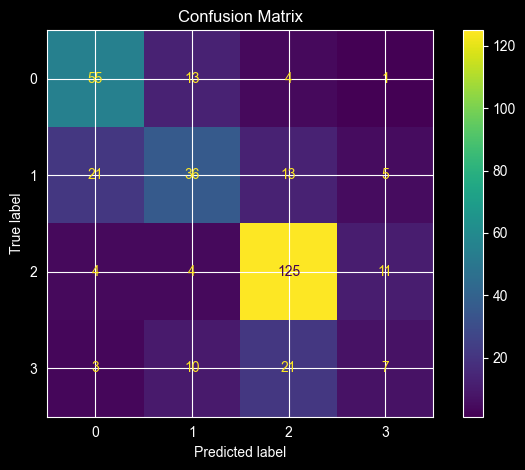

In [8]:
y_pred=model.predict(X_test)
print(classification_report(Y_test,y_pred))

cv_results = cross_val_score(model, X_train, Y_train, cv=5)
print(f'Cross Validation be like: {cv_results.mean():.3f} +- {cv_results.std():.3f}')

ConfusionMatrixDisplay.from_estimator(
    model, X_test, Y_test
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Feature importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

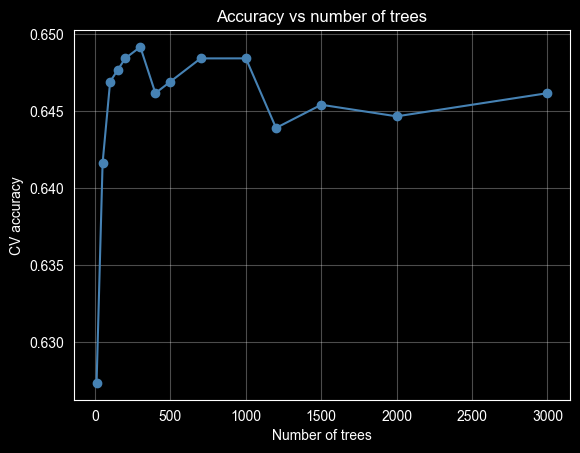

In [14]:
n_trees_range = [10, 50, 100, 150, 200, 300, 400, 500, 700, 1000, 1200, 1500, 2000, 3000 ]
scores = []

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n,
    max_features=0.5,
    criterion='gini',
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    max_depth=None,
    n_jobs=-1)
    score = cross_val_score(rf, X_train, Y_train, cv=3).mean()
    scores.append(score)

plt.plot(n_trees_range, scores, marker="o", color="steelblue")
plt.xlabel("Number of trees")
plt.ylabel("CV accuracy")
plt.title("Accuracy vs number of trees")
plt.grid(True, alpha=0.3)
plt.show()

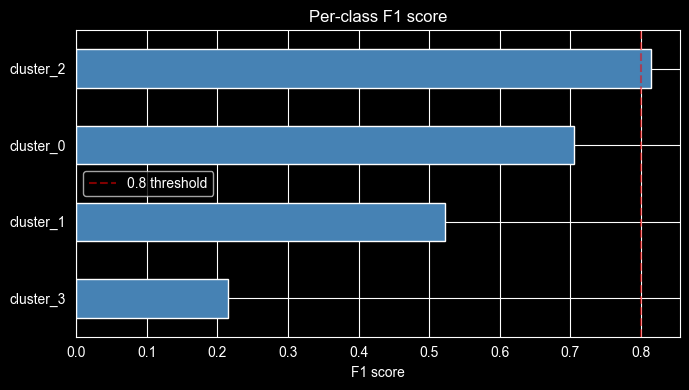

In [9]:
report = classification_report(Y_test, y_pred,
                               target_names=class_names,
                               output_dict=True)

f1_scores = {cls: report[cls]["f1-score"] for cls in class_names}
pd.Series(f1_scores).sort_values().plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.xlabel("F1 score")
plt.title("Per-class F1 score")
plt.axvline(x=0.8, color="red", linestyle="--", alpha=0.5, label="0.8 threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
print(Y_train.value_counts())

cluster_results_KMedoids
2    574
1    300
0    294
3    163
Name: count, dtype: int64


In [6]:
param_grid = {
    "n_estimators":     [200, 400, 600,400, 500, 700, 1000, 1200],
    "max_depth":        [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
    "max_features":     ["sqrt", "log2", 0.5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="f1_macro",   # macro F1 is better than accuracy for imbalanced classes
    n_jobs=-1
)
grid.fit(X_train, Y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)
model = grid.best_estimator_

C:\Users\Izumiko\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'criterion': 'gini', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}
Best score: 0.5580474776609706
